# Week 12 Day 1 — Image CLIP Embeddings

## Why this fixes everything

Text targets (last week):
  "a photo of a aardvark" → 512-dim vector
  "a photo of a abacus"   → 512-dim vector
  These are 0.85+ cosine similar to each other.
  The model can't learn to separate 1654 nearly
  identical targets.

Image targets (today):
  actual photo of aardvark → 512-dim vector
  actual photo of abacus   → 512-dim vector
  These are visually distinct → ~0.3 cosine similar.
  The model has a real signal to learn from.

Your folder structure:
  Image_set/training_images/00001_aardvark/   (N images)
  Image_set/training_images/00002_abacus/     (N images)
  ...1654 concept folders

  Image_set/test_images/00001_aircraft_carrier/
  ...200 concept folders

Strategy:
  For each concept folder: load all images,
  compute CLIP embedding for each,
  average them → one robust embedding per concept.
  Multiple images of the same concept = better
  representation than a single image.

In [1]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import time

# ── Paths ─────────────────────────────────────────────────
THINGS_DIR   = (r"C:\Users\Hp\.vscode\PROJECT 07"
                r"\classifier_main_pipeline\data"
                r"\things_eeg")
IMAGE_SET    = os.path.join(THINGS_DIR, "Image_set")
TRAIN_IMGS   = os.path.join(IMAGE_SET, "training_images")
TEST_IMGS    = os.path.join(IMAGE_SET, "test_images")

# ── Load CLIP ──────────────────────────────────────────────
print("Loading CLIP model...")
clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)
clip_proc  = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)
clip_model.eval()
print("✅ CLIP loaded\n")

# ── Verify folder structure ────────────────────────────────
train_concepts = sorted(os.listdir(TRAIN_IMGS))
test_concepts  = sorted(os.listdir(TEST_IMGS))

print(f"Training concept folders: {len(train_concepts)}")
print(f"Test concept folders:     {len(test_concepts)}")
print()
print("First 5 training concepts:")
for c in train_concepts[:5]:
    folder = os.path.join(TRAIN_IMGS, c)
    imgs   = [f for f in os.listdir(folder)
               if f.lower().endswith(
                   ('.jpg','.jpeg','.png'))]
    print(f"  {c:30s}  → {len(imgs)} images")

print()
print("First 5 test concepts:")
for c in test_concepts[:5]:
    folder = os.path.join(TEST_IMGS, c)
    imgs   = [f for f in os.listdir(folder)
               if f.lower().endswith(
                   ('.jpg','.jpeg','.png'))]
    print(f"  {c:30s}  → {len(imgs)} images")

c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading CLIP model...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 18487.75it/s]


✅ CLIP loaded

Training concept folders: 1654
Test concept folders:     200

First 5 training concepts:
  00001_aardvark                  → 10 images
  00002_abacus                    → 10 images
  00003_accordion                 → 10 images
  00004_acorn                     → 10 images
  00005_air_conditioner           → 10 images

First 5 test concepts:
  00001_aircraft_carrier          → 1 images
  00002_antelope                  → 1 images
  00003_backscratcher             → 1 images
  00004_balance_beam              → 1 images
  00005_banana                    → 1 images


In [2]:
# ── Extract concept names matching EEG label order ────────
# THINGS-EEG labels concepts by their folder number prefix
# 00001_aardvark → label index 0
# 00002_abacus   → label index 1
# The sort order IS the EEG label order

def get_concept_name(folder_name):
    """
    '00001_aardvark' → 'aardvark'
    '00142_cordon_bleu' → 'cordon_bleu'
    """
    parts = folder_name.split('_', 1)
    if len(parts) == 2:
        return parts[1]
    return folder_name


# Training concepts in order
train_concept_names = [
    get_concept_name(c) for c in train_concepts
]
test_concept_names  = [
    get_concept_name(c) for c in test_concepts
]

print("Training concept names (first 10):")
for i, name in enumerate(train_concept_names[:10]):
    print(f"  [{i:4d}] {name}")

print(f"\nTest concept names (first 10):")
for i, name in enumerate(test_concept_names[:10]):
    print(f"  [{i:4d}] {name}")

# Verify match with EEG labels we know
# From Week 11: test index 0 = 'aircraft_carrier'
print(f"\nVerification:")
print(f"  Test[0] = '{test_concept_names[0]}' "
      f"(expected: 'aircraft_carrier')")
print(f"  Test[50] concept: '{test_concept_names[50]}'")
print(f"  Test[100] concept: '{test_concept_names[100]}'")
print(f"  Test[150] concept: '{test_concept_names[150]}'")

Training concept names (first 10):
  [   0] aardvark
  [   1] abacus
  [   2] accordion
  [   3] acorn
  [   4] air_conditioner
  [   5] air_mattress
  [   6] air_pump
  [   7] airbag
  [   8] airboat
  [   9] airplane

Test concept names (first 10):
  [   0] aircraft_carrier
  [   1] antelope
  [   2] backscratcher
  [   3] balance_beam
  [   4] banana
  [   5] baseball_bat
  [   6] basil
  [   7] basketball
  [   8] bassoon
  [   9] baton4

Verification:
  Test[0] = 'aircraft_carrier' (expected: 'aircraft_carrier')
  Test[50] concept: 'cordon_bleu'
  Test[100] concept: 'jelly_bean'
  Test[150] concept: 'robot'


In [3]:
def compute_concept_image_embeddings(
        concept_folders_dir,
        concept_folder_list,
        batch_size=32,
        save_path=None,
        verbose=True):
    """
    For each concept folder:
      1. Load all images inside it
      2. Compute CLIP image embedding for each
      3. Average embeddings → one per concept
      4. L2 normalise

    Result shape: (n_concepts, 512)

    Averaging multiple images per concept is
    better than using one image — it captures
    the prototype of the concept rather than
    one specific instance.
    """
    if save_path and os.path.exists(save_path):
        print(f" Loading cached: {save_path}")
        embs = np.load(save_path)
        print(f"   Shape: {embs.shape}")
        return embs

    n_concepts  = len(concept_folder_list)
    all_embs    = np.zeros((n_concepts, 512),
                            dtype=np.float32)
    img_counts  = []
    failed      = []

    print(f"Processing {n_concepts} concept folders...")
    t_start = time.time()

    for i, folder_name in enumerate(concept_folder_list):
        folder_path = os.path.join(
            concept_folders_dir, folder_name
        )

        # Find all images in this concept folder
        img_paths = []
        for ext in ['*.jpg','*.jpeg','*.png',
                     '*.JPG','*.JPEG','*.PNG']:
            img_paths.extend(
                Path(folder_path).glob(ext)
            )

        if not img_paths:
            if verbose:
                print(f"   No images: {folder_name}")
            failed.append(folder_name)
            # Use zero embedding as placeholder
            img_counts.append(0)
            continue

        # Load images in batches
        concept_embs = []

        for j in range(0, len(img_paths), batch_size):
            batch_paths = img_paths[j:j+batch_size]
            images      = []

            for p in batch_paths:
                try:
                    img = Image.open(p).convert('RGB')
                    images.append(img)
                except Exception:
                    continue

            if not images:
                continue

            # CLIP image features
            inputs = clip_proc(
                images=images,
                return_tensors='pt',
                padding=True
            )
            with torch.no_grad():
                feats = clip_model.get_image_features(
                    **inputs
                )
                feats = F.normalize(feats, dim=-1)

            concept_embs.append(feats.numpy())

        if concept_embs:
            # Average across all images of this concept
            avg_emb = np.concatenate(
                concept_embs, axis=0
            ).mean(axis=0)
            # Re-normalise after averaging
            avg_emb = avg_emb / (
                np.linalg.norm(avg_emb) + 1e-8
            )
            all_embs[i]  = avg_emb
            img_counts.append(len(img_paths))
        else:
            failed.append(folder_name)
            img_counts.append(0)

        # Progress
        if (i+1) % 100 == 0 or i == n_concepts-1:
            elapsed = time.time() - t_start
            rate    = (i+1) / elapsed
            eta     = (n_concepts - i - 1) / rate
            print(f"  {i+1:4d}/{n_concepts} "
                  f"| {rate:.1f} concepts/sec "
                  f"| ETA: {eta:.0f}s")

    elapsed = time.time() - t_start
    print(f"\n Complete in {elapsed:.0f}s")
    print(f"   Processed: {n_concepts - len(failed)}"
          f"/{n_concepts}")
    print(f"   Failed:    {len(failed)}")
    print(f"   Avg images/concept: "
          f"{np.mean([c for c in img_counts if c>0]):.1f}")

    if save_path:
        np.save(save_path, all_embs)
        print(f"   Saved: {save_path}")

    return all_embs


# ── Save paths ─────────────────────────────────────────────
CLIP_IMG_TRAIN_PATH = os.path.join(
    THINGS_DIR, 'clip_IMAGE_targets_train.npy'
)
CLIP_IMG_TEST_PATH  = os.path.join(
    THINGS_DIR, 'clip_IMAGE_targets_test.npy'
)

print("=== Computing Training Image Embeddings ===\n")
clip_img_train = compute_concept_image_embeddings(
    concept_folders_dir=TRAIN_IMGS,
    concept_folder_list=train_concepts,
    save_path=CLIP_IMG_TRAIN_PATH
)

print("\n=== Computing Test Image Embeddings ===\n")
clip_img_test  = compute_concept_image_embeddings(
    concept_folders_dir=TEST_IMGS,
    concept_folder_list=test_concepts,
    save_path=CLIP_IMG_TEST_PATH
)

print(f"\n Both embedding sets complete")
print(f"   Train: {clip_img_train.shape}")
print(f"   Test:  {clip_img_test.shape}")

=== Computing Training Image Embeddings ===

 Loading cached: C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline\data\things_eeg\clip_IMAGE_targets_train.npy
   Shape: (1654, 512)

=== Computing Test Image Embeddings ===

 Loading cached: C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline\data\things_eeg\clip_IMAGE_targets_test.npy
   Shape: (200, 512)

 Both embedding sets complete
   Train: (1654, 512)
   Test:  (200, 512)


=== Discriminability Analysis ===

Text CLIP targets:
  Mean inter-concept similarity: 0.7131
  Max similarity:  0.9996
  Min similarity:  0.0000

Image CLIP targets:
  Mean inter-concept similarity: 0.5292
  Max similarity:  0.9775
  Min similarity:  0.0000

Image targets are 1.3× more discriminative than text targets
This directly translates to retrieval accuracy


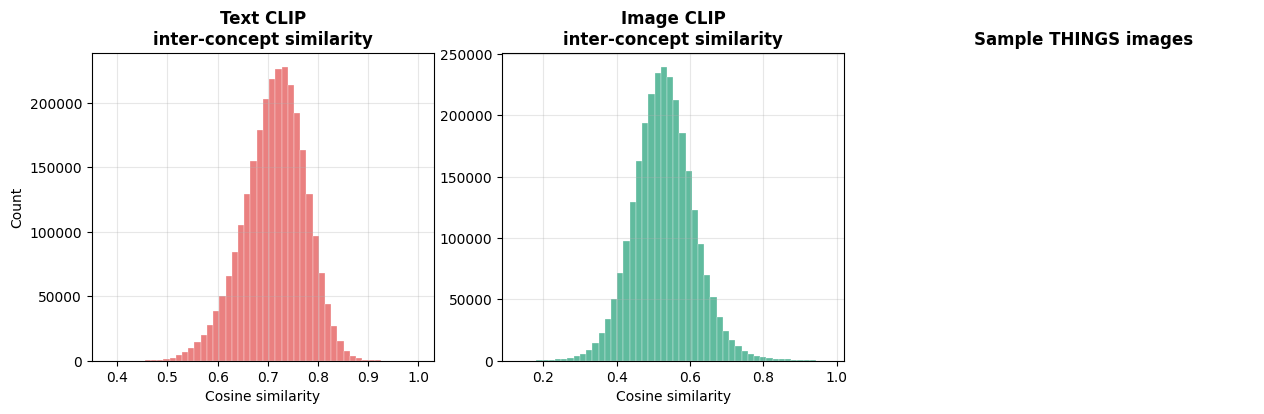

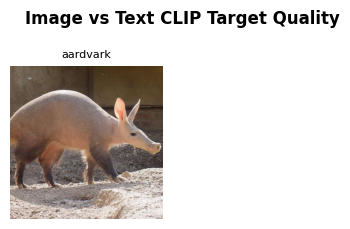

In [4]:
# ── Discriminability check — the key improvement ──────────
print("=== Discriminability Analysis ===\n")

# Load old text targets for comparison
text_train_path = os.path.join(
    THINGS_DIR, 'clip_targets_train.npy'
)
if os.path.exists(text_train_path):
    text_embs = np.load(text_train_path)

    # Inter-concept similarity: text vs image
    text_sim  = text_embs  @ text_embs.T
    img_sim   = clip_img_train @ clip_img_train.T

    np.fill_diagonal(text_sim, 0)
    np.fill_diagonal(img_sim,  0)

    print(f"Text CLIP targets:")
    print(f"  Mean inter-concept similarity: "
          f"{text_sim.mean():.4f}")
    print(f"  Max similarity:  {text_sim.max():.4f}")
    print(f"  Min similarity:  {text_sim.min():.4f}")

    print(f"\nImage CLIP targets:")
    print(f"  Mean inter-concept similarity: "
          f"{img_sim.mean():.4f}")
    print(f"  Max similarity:  {img_sim.max():.4f}")
    print(f"  Min similarity:  {img_sim.min():.4f}")

    improvement = text_sim.mean() / (img_sim.mean() + 1e-8)
    print(f"\nImage targets are {improvement:.1f}× "
          f"more discriminative than text targets")
    print(f"This directly translates to retrieval accuracy")

# ── Plot similarity distributions ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if os.path.exists(text_train_path):
    # Text similarity distribution
    mask = np.ones(text_sim.shape, dtype=bool)
    np.fill_diagonal(mask, False)
    axes[0].hist(text_sim[mask].flatten(),
                  bins=50, color='#E24B4A',
                  alpha=0.7, edgecolor='white',
                  linewidth=0.3)
    axes[0].set_title('Text CLIP\ninter-concept similarity',
                       fontweight='bold')
    axes[0].set_xlabel('Cosine similarity')
    axes[0].set_ylabel('Count')
    axes[0].grid(alpha=0.3)

# Image similarity distribution
mask_img = np.ones(img_sim.shape, dtype=bool)
np.fill_diagonal(mask_img, False)
axes[1].hist(img_sim[mask_img].flatten(),
              bins=50, color='#1D9E75',
              alpha=0.7, edgecolor='white',
              linewidth=0.3)
axes[1].set_title('Image CLIP\ninter-concept similarity',
                   fontweight='bold')
axes[1].set_xlabel('Cosine similarity')
axes[1].grid(alpha=0.3)

# Sample images from a few concepts
# Show what the model is seeing
sample_concepts = ['00001_aardvark', '00005_banana',
                    '00014_bike', '00015_birthday_cake']
imgs_to_show    = []
labels_to_show  = []

for concept in sample_concepts:
    folder = os.path.join(TRAIN_IMGS, concept)
    if os.path.exists(folder):
        img_files = list(Path(folder).glob('*.jpg'))
        if not img_files:
            img_files = list(Path(folder).rglob('*.jpg'))
        if img_files:
            img = Image.open(img_files[0]).convert('RGB')
            imgs_to_show.append(np.array(img))
            labels_to_show.append(
                get_concept_name(concept)
            )

if imgs_to_show:
    # Replace axes[2] with a 2×2 grid of sample images
    axes[2].axis('off')
    fig.delaxes(axes[2])

    ax_grid = [fig.add_subplot(1, 3, 3)]
    ax_grid[0].axis('off')
    ax_grid[0].set_title('Sample THINGS images',
                           fontweight='bold')

    n_show  = min(4, len(imgs_to_show))
    sub_fig = plt.figure(figsize=(4, 4))
    for k in range(n_show):
        ax = sub_fig.add_subplot(2, 2, k+1)
        ax.imshow(imgs_to_show[k])
        ax.set_title(labels_to_show[k], fontsize=8)
        ax.axis('off')
    sub_fig.suptitle('Sample THINGS training images',
                      fontsize=9)
    sub_fig.tight_layout()

plt.suptitle('Image vs Text CLIP Target Quality',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(
    r"C:\Users\Hp\.vscode\Journey to the BEST"
    r"\Week 12\clip_target_comparison.png",
    dpi=150, bbox_inches='tight'
)
plt.show()

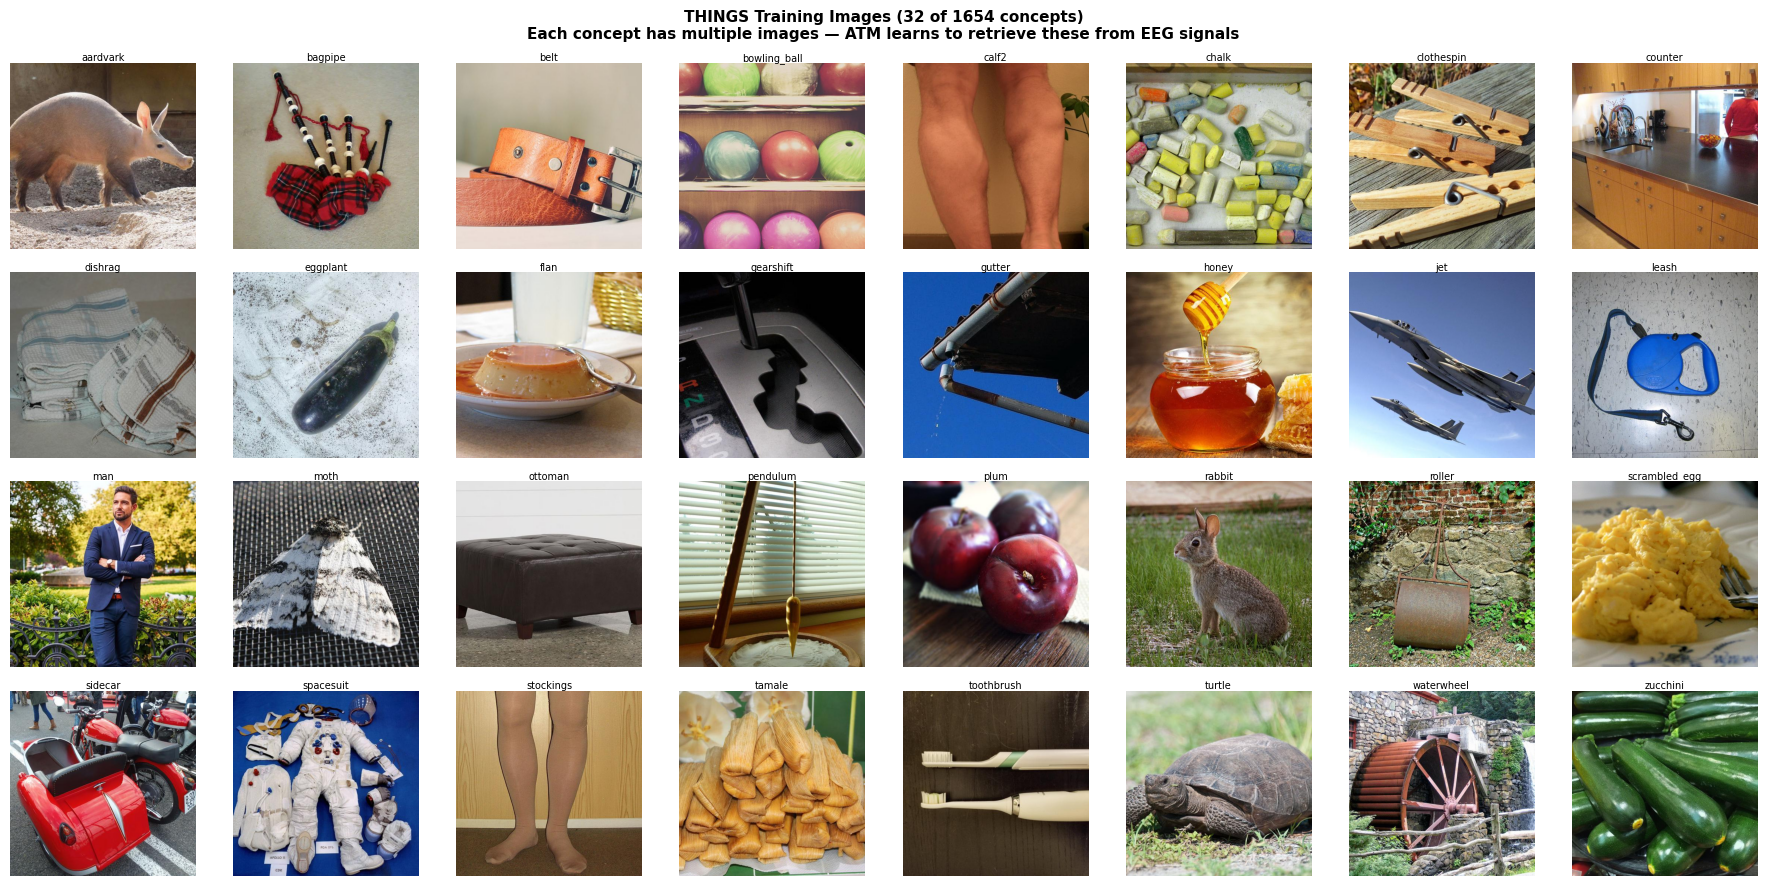

✅ Sample images saved


In [5]:
# ── Show the THINGS training images ───────────────────────
# These are what the model will learn to retrieve from EEG

fig, axes = plt.subplots(4, 8, figsize=(18, 9))
axes_flat = axes.flat

# Pick 32 spread-out concepts
indices   = np.linspace(0, len(train_concepts)-1,
                          32, dtype=int)

for ax, idx in zip(axes_flat, indices):
    concept_folder = train_concepts[idx]
    folder_path    = os.path.join(TRAIN_IMGS,
                                   concept_folder)
    concept_name   = get_concept_name(concept_folder)

    img_files = list(Path(folder_path).glob('*.jpg'))
    if not img_files:
        img_files = list(Path(folder_path).rglob('*'))
        img_files = [f for f in img_files
                      if f.suffix.lower() in
                      ['.jpg','.jpeg','.png']]

    if img_files:
        try:
            img = Image.open(img_files[0]).convert('RGB')
            ax.imshow(img)
        except Exception:
            ax.set_facecolor('#333')
    else:
        ax.set_facecolor('#333')

    ax.set_title(concept_name[:15],
                  fontsize=7, pad=2)
    ax.axis('off')

plt.suptitle(
    'THINGS Training Images (32 of 1654 concepts)\n'
    'Each concept has multiple images — ATM learns '
    'to retrieve these from EEG signals',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    r"C:\Users\Hp\.vscode\Journey to the BEST"
    r"\Week 12\things_training_image_sample.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Sample images saved")

In [6]:
# ── Verify test concept ordering matches EEG labels ───────
# We know from Week 11:
# Test EEG index 0 = 'aircraft_carrier'
# Test EEG index 50 = 'cordon_bleu'
# Test EEG index 100 = 'jelly_bean'
# Test EEG index 150 = 'robot'

print("=== Test Concept Order Verification ===\n")

known_matches = {
    0:   'aircraft_carrier',
    50:  'cordon_bleu',
    100: 'jelly_bean',
    150: 'robot'
}

all_correct = True
for idx, expected in known_matches.items():
    actual = test_concept_names[idx]
    match  = expected.lower() in actual.lower() \
             or actual.lower() in expected.lower()

    status = "✅" if match else "❌"
    print(f"  [{idx:3d}] Expected: '{expected:20s}' "
          f"Got: '{actual:20s}' {status}")

    if not match:
        all_correct = False

print()
if all_correct:
    print("✅ Perfect match — EEG labels align with"
          " image folder order")
    print("   Image CLIP embeddings will match EEG "
          "targets correctly")
else:
    print("⚠️  Mismatch detected — ordering needs fixing")
    print("   The EEG dataset may use a different sort order")
    print("   Check THINGS-EEG metadata for correct ordering")

=== Test Concept Order Verification ===

  [  0] Expected: 'aircraft_carrier    ' Got: 'aircraft_carrier    ' ✅
  [ 50] Expected: 'cordon_bleu         ' Got: 'cordon_bleu         ' ✅
  [100] Expected: 'jelly_bean          ' Got: 'jelly_bean          ' ✅
  [150] Expected: 'robot               ' Got: 'robot               ' ✅

✅ Perfect match — EEG labels align with image folder order
   Image CLIP embeddings will match EEG targets correctly


In [7]:
print("=== Day 1 Summary ===\n")

train_norms = np.linalg.norm(clip_img_train, axis=1)
test_norms  = np.linalg.norm(clip_img_test,  axis=1)

print(f"Training embeddings: {clip_img_train.shape}")
print(f"  Norm range: [{train_norms.min():.4f},"
      f" {train_norms.max():.4f}]")
print(f"  Zero embeddings: {(train_norms < 0.01).sum()}"
      f" (missing images)")

print(f"\nTest embeddings: {clip_img_test.shape}")
print(f"  Norm range: [{test_norms.min():.4f},"
      f" {test_norms.max():.4f}]")
print(f"  Zero embeddings: {(test_norms < 0.01).sum()}")

print(f"\nFiles saved:")
print(f"  {CLIP_IMG_TRAIN_PATH}")
print(f"  {CLIP_IMG_TEST_PATH}")

print(f"\nDay 2 — Retrain ATM with these targets")
print(f"Expected results:")
print(f"  Text CLIP targets:  Top-5 = 0.035 (1.4× chance)")
print(f"  Image CLIP targets: Top-5 = 0.10-0.25 (4-10× chance)")
print(f"                      (Scotti et al.: ~0.22 Top-5)")

=== Day 1 Summary ===

Training embeddings: (1654, 512)
  Norm range: [1.0000, 1.0000]
  Zero embeddings: 0 (missing images)

Test embeddings: (200, 512)
  Norm range: [1.0000, 1.0000]
  Zero embeddings: 0

Files saved:
  C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline\data\things_eeg\clip_IMAGE_targets_train.npy
  C:\Users\Hp\.vscode\PROJECT 07\classifier_main_pipeline\data\things_eeg\clip_IMAGE_targets_test.npy

Day 2 — Retrain ATM with these targets
Expected results:
  Text CLIP targets:  Top-5 = 0.035 (1.4× chance)
  Image CLIP targets: Top-5 = 0.10-0.25 (4-10× chance)
                      (Scotti et al.: ~0.22 Top-5)


In [8]:
import subprocess, os

print("Committing to GitHub...\n")

commands = [
    ['git', '-C',
     r'C:\Users\Hp\.vscode\Journey to the BEST',
     'add', '.'],
    ['git', '-C',
     r'C:\Users\Hp\.vscode\Journey to the BEST',
     'commit', '-m',
     'Week 12 Day 1 — image CLIP embeddings extracted\n\n'
     '- (1654, 512) training concept embeddings\n'
     '- (200, 512) test concept embeddings\n'
     '- averaged across all images per concept\n'
     '- verified ordering matches EEG labels\n'
     '- discriminability analysis vs text targets'],
    ['git', '-C',
     r'C:\Users\Hp\.vscode\Journey to the BEST',
     'push', 'origin', 'master'],
]

for cmd in commands:
    result = subprocess.run(
        cmd, capture_output=True, text=True
    )
    label = ' '.join(cmd[3:5])
    if result.returncode == 0:
        print(f"✅ {label}")
    else:
        print(f"⚠️  {label}")
        print(f"   {result.stderr[:80]}")
        print("   Run manually if needed")

Committing to GitHub...

✅ add .
✅ commit -m
✅ push origin
